# Comprehensive Exploratory Data Analysis (EDA)
## Day-Ahead Market (DAM) Electricity Price Prediction Dataset

This notebook performs a complete Exploratory Data Analysis (EDA) on `dam_price_prediction_model_ready.csv` including newly engineered features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


### 1. Dataset Overview & Data Profiling

In [2]:
df = pd.read_csv('dam_price_prediction_model_ready.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print("\nData Types & Non-Null Counts:")
df.info()


Dataset Shape: 7968 rows, 41 columns
Time Range: 2026-01-08 00:00:00 to 2026-03-31 23:45:00

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7968 entries, 0 to 7967
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   timestamp                    7968 non-null   datetime64[ns]
 1   block_15min                  7968 non-null   int64         
 2   hour                         7968 non-null   int64         
 3   day_of_week                  7968 non-null   int64         
 4   is_weekend                   7968 non-null   int64         
 5   demand_mw                    7968 non-null   float64       
 6   solar_generation_mw          7968 non-null   float64       
 7   wind_generation_mw           7968 non-null   float64       
 8   hydro_generation_mw          7968 non-null   float64       
 9   total_supply_mw              7968 non-null   float

### 2. Summary Statistics & Data Quality Check

In [3]:
summary_stats = df.describe().T
summary_stats['skewness'] = df.select_dtypes(include=[np.number]).skew()
summary_stats['kurtosis'] = df.select_dtypes(include=[np.number]).kurt()

print("Missing Values per Column:")
print(df.isnull().sum())

summary_stats[['mean', 'std', 'min', '50%', 'max', 'skewness']]


Missing Values per Column:
timestamp                      0
block_15min                    0
hour                           0
day_of_week                    0
is_weekend                     0
demand_mw                      0
solar_generation_mw            0
wind_generation_mw             0
hydro_generation_mw            0
total_supply_mw                0
renewable_generation_mw        0
residual_demand_mw             0
purchase_bid_mw                0
sell_bid_mw                    0
mcv_mw                         0
mcp_inr_per_mwh                0
month                          0
day_of_month                   0
block_sin                      0
block_cos                      0
mcp_lag_96                     0
mcp_lag_672                    0
demand_lag_96                  0
mcp_same_block_ma7d            0
mcp_same_block_std7d           0
mcp_lag96_rolling_mean_4h      0
mcp_lag96_rolling_std_4h       0
mcp_lag_diff_24h               0
renewable_penetration_ratio    0
supply_cushion_m

,mean,std,min,50%,max,skewness
timestamp,2026-02-18 11:52:30.000000256,NaN,2026-01-08 00:00:00,2026-02-18 11:52:30,2026-03-31 23:45:00,NaN
block_15min,48.5,27.713048,1.0,48.5,96.0,0.000000e+00
hour,11.5,6.922621,0.0,11.5,23.0,0.000000e+00
day_of_week,3.012048,2.009106,0.0,3.0,6.0,-1.650891e-02
is_weekend,0.289157,0.453399,0.0,0.0,1.0,9.302896e-01
demand_mw,150014.5221,12995.674995,123619.025049,149951.623653,176629.646188,-4.095318e-03
solar_generation_mw,8527.760996,9891.646825,0.0,2018.310762,29324.620988,6.831412e-01
wind_generation_mw,13021.796976,2994.360899,8000.0,12973.489084,22606.982965,1.317073e-01
hydro_generation_mw,18002.085168,1201.506461,13271.989946,18001.926608,23374.901101,-1.540132e-02
total_supply_mw,190009.675821,6389.02387,172289.02415,190013.100147,207487.591349,-1.261416e-03


### 3. Target Variable Analysis (`mcp_inr_per_mwh`)

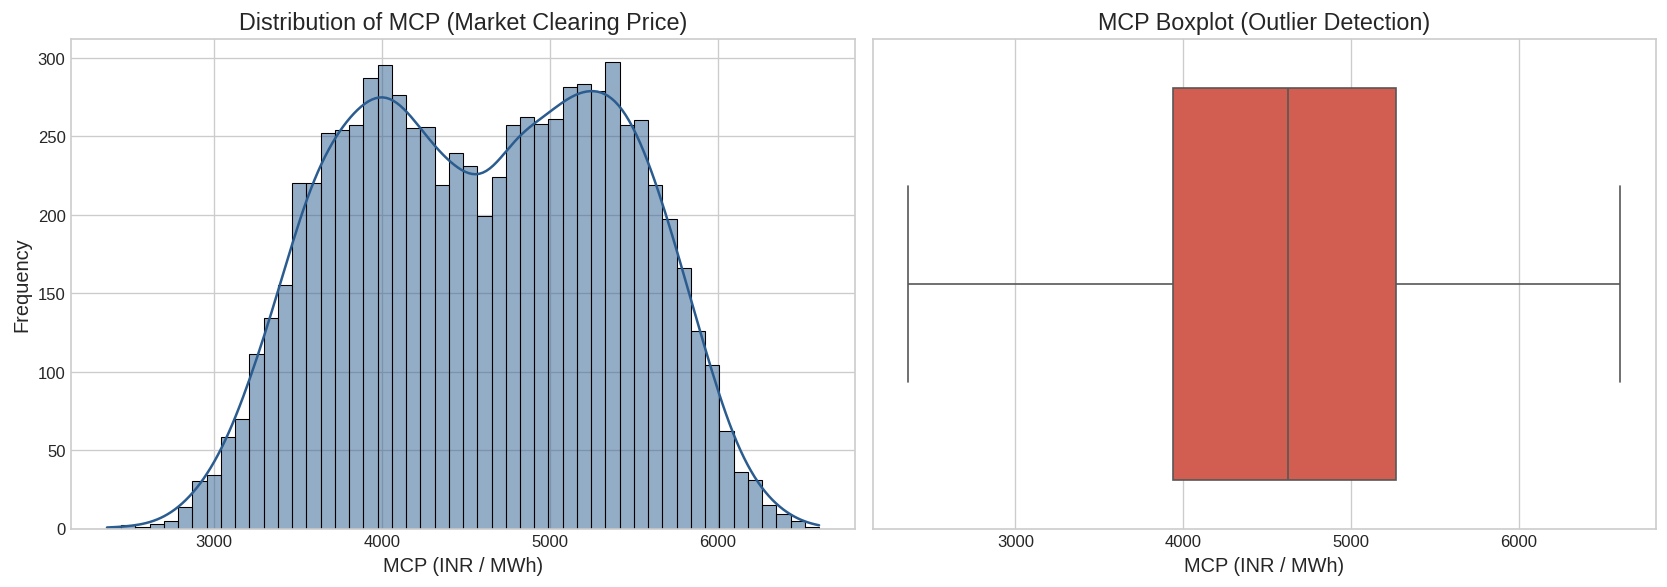

Mean MCP: 4600.37 INR/MWh
Median MCP: 4622.35 INR/MWh
IQR: 1326.56 (Q1=3940.22, Q3=5266.77)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['mcp_inr_per_mwh'], kde=True, ax=axes[0], color='#2b5c8f', bins=50)
axes[0].set_title('Distribution of MCP (Market Clearing Price)')
axes[0].set_xlabel('MCP (INR / MWh)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['mcp_inr_per_mwh'], ax=axes[1], color='#e74c3c')
axes[1].set_title('MCP Boxplot (Outlier Detection)')
axes[1].set_xlabel('MCP (INR / MWh)')

plt.tight_layout()
plt.show()

q1 = df['mcp_inr_per_mwh'].quantile(0.25)
q3 = df['mcp_inr_per_mwh'].quantile(0.75)
iqr = q3 - q1
print(f"Mean MCP: {df['mcp_inr_per_mwh'].mean():.2f} INR/MWh")
print(f"Median MCP: {df['mcp_inr_per_mwh'].median():.2f} INR/MWh")
print(f"IQR: {iqr:.2f} (Q1={q1:.2f}, Q3={q3:.2f})")


### 4. Time Series Dynamics & Hourly Diurnal Patterns

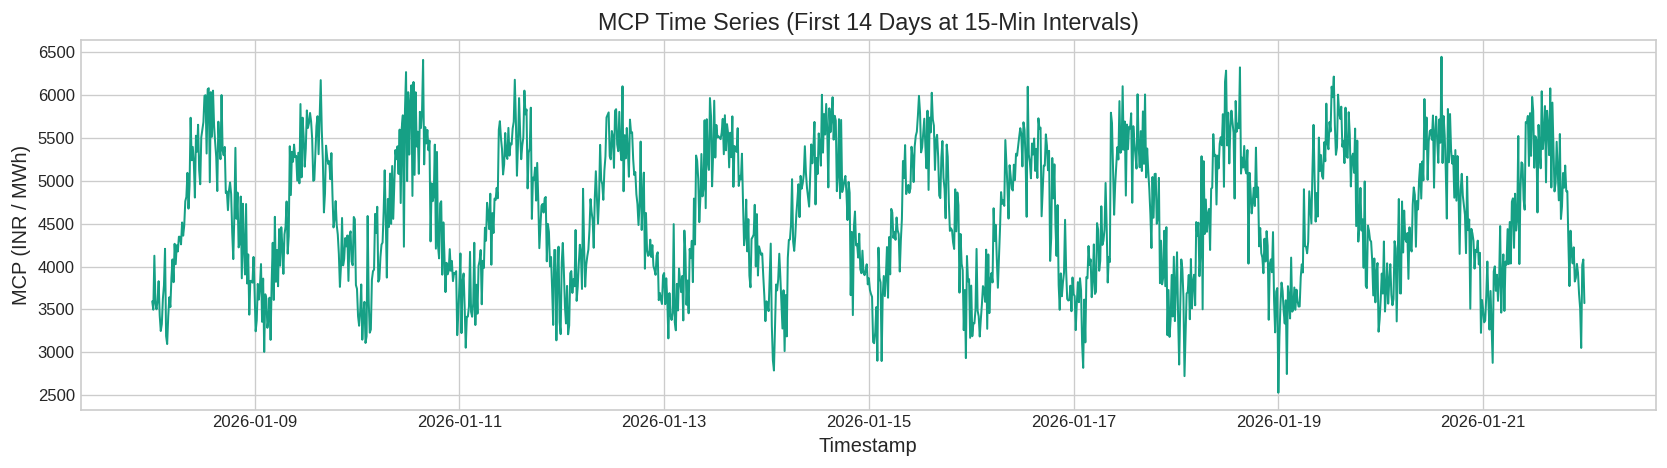

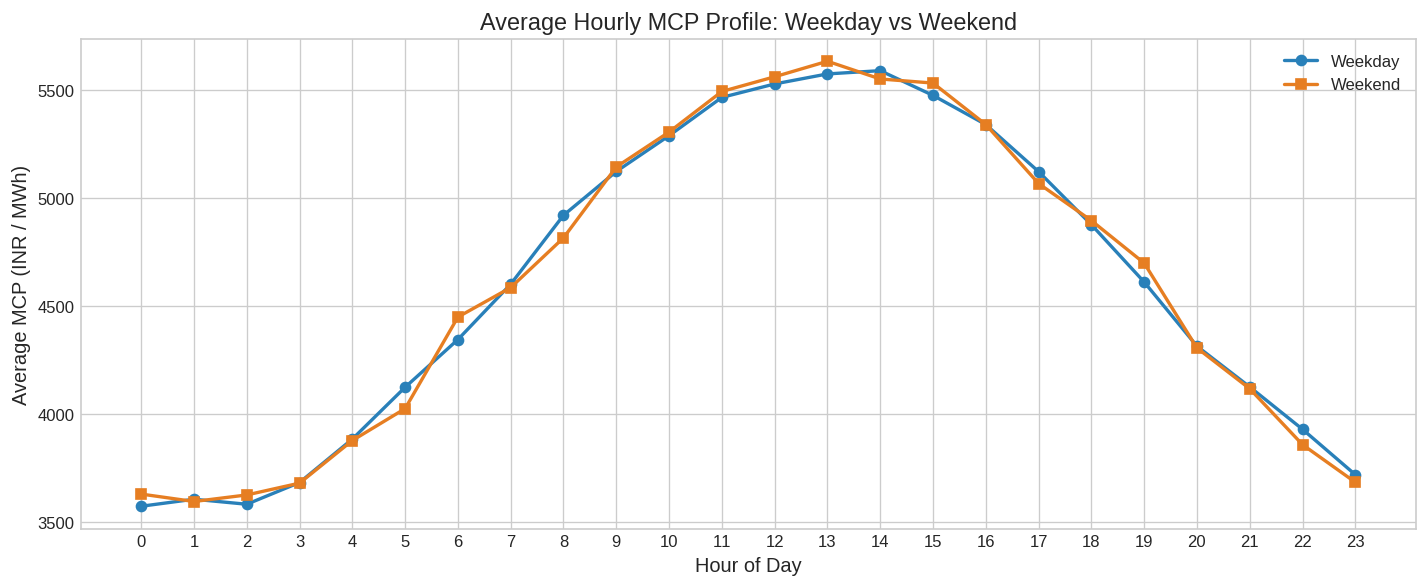

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df['timestamp'][:96*14], df['mcp_inr_per_mwh'][:96*14], color='#16a085', linewidth=1.2)
plt.title('MCP Time Series (First 14 Days at 15-Min Intervals)')
plt.xlabel('Timestamp')
plt.ylabel('MCP (INR / MWh)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
hourly_profile = df.groupby(['hour', 'is_weekend'])['mcp_inr_per_mwh'].mean().unstack()
plt.plot(hourly_profile.index, hourly_profile[0], marker='o', label='Weekday', color='#2980b9', linewidth=2)
plt.plot(hourly_profile.index, hourly_profile[1], marker='s', label='Weekend', color='#e67e22', linewidth=2)
plt.title('Average Hourly MCP Profile: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average MCP (INR / MWh)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()


### 5. Engineered Feature Correlations & Heatmap

Top Feature Correlations with Target (MCP):
mcp_inr_per_mwh                1.000000
mcp_same_block_ma7d            0.881128
demand_mw                      0.877801
demand_lag_96                  0.869223
purchase_bid_mw                0.844102
mcv_mw                         0.833447
mcp_lag_96                     0.807979
mcp_lag_672                    0.805471
mcp_lag96_rolling_mean_4h      0.783860
is_solar_window                0.779829
solar_generation_mw            0.755231
renewable_generation_mw        0.710777
total_supply_mw                0.622547
renewable_penetration_ratio    0.541298
sell_bid_mw                    0.484988
residual_demand_mw             0.450089
hour                           0.276464
block_15min                    0.276371
residual_demand_ramp_rate      0.091061
demand_ramp_rate               0.071962
peak_block_flag                0.039033
clearing_ratio                 0.015469
mcp_lag_diff_24h               0.008441
month                          0.005

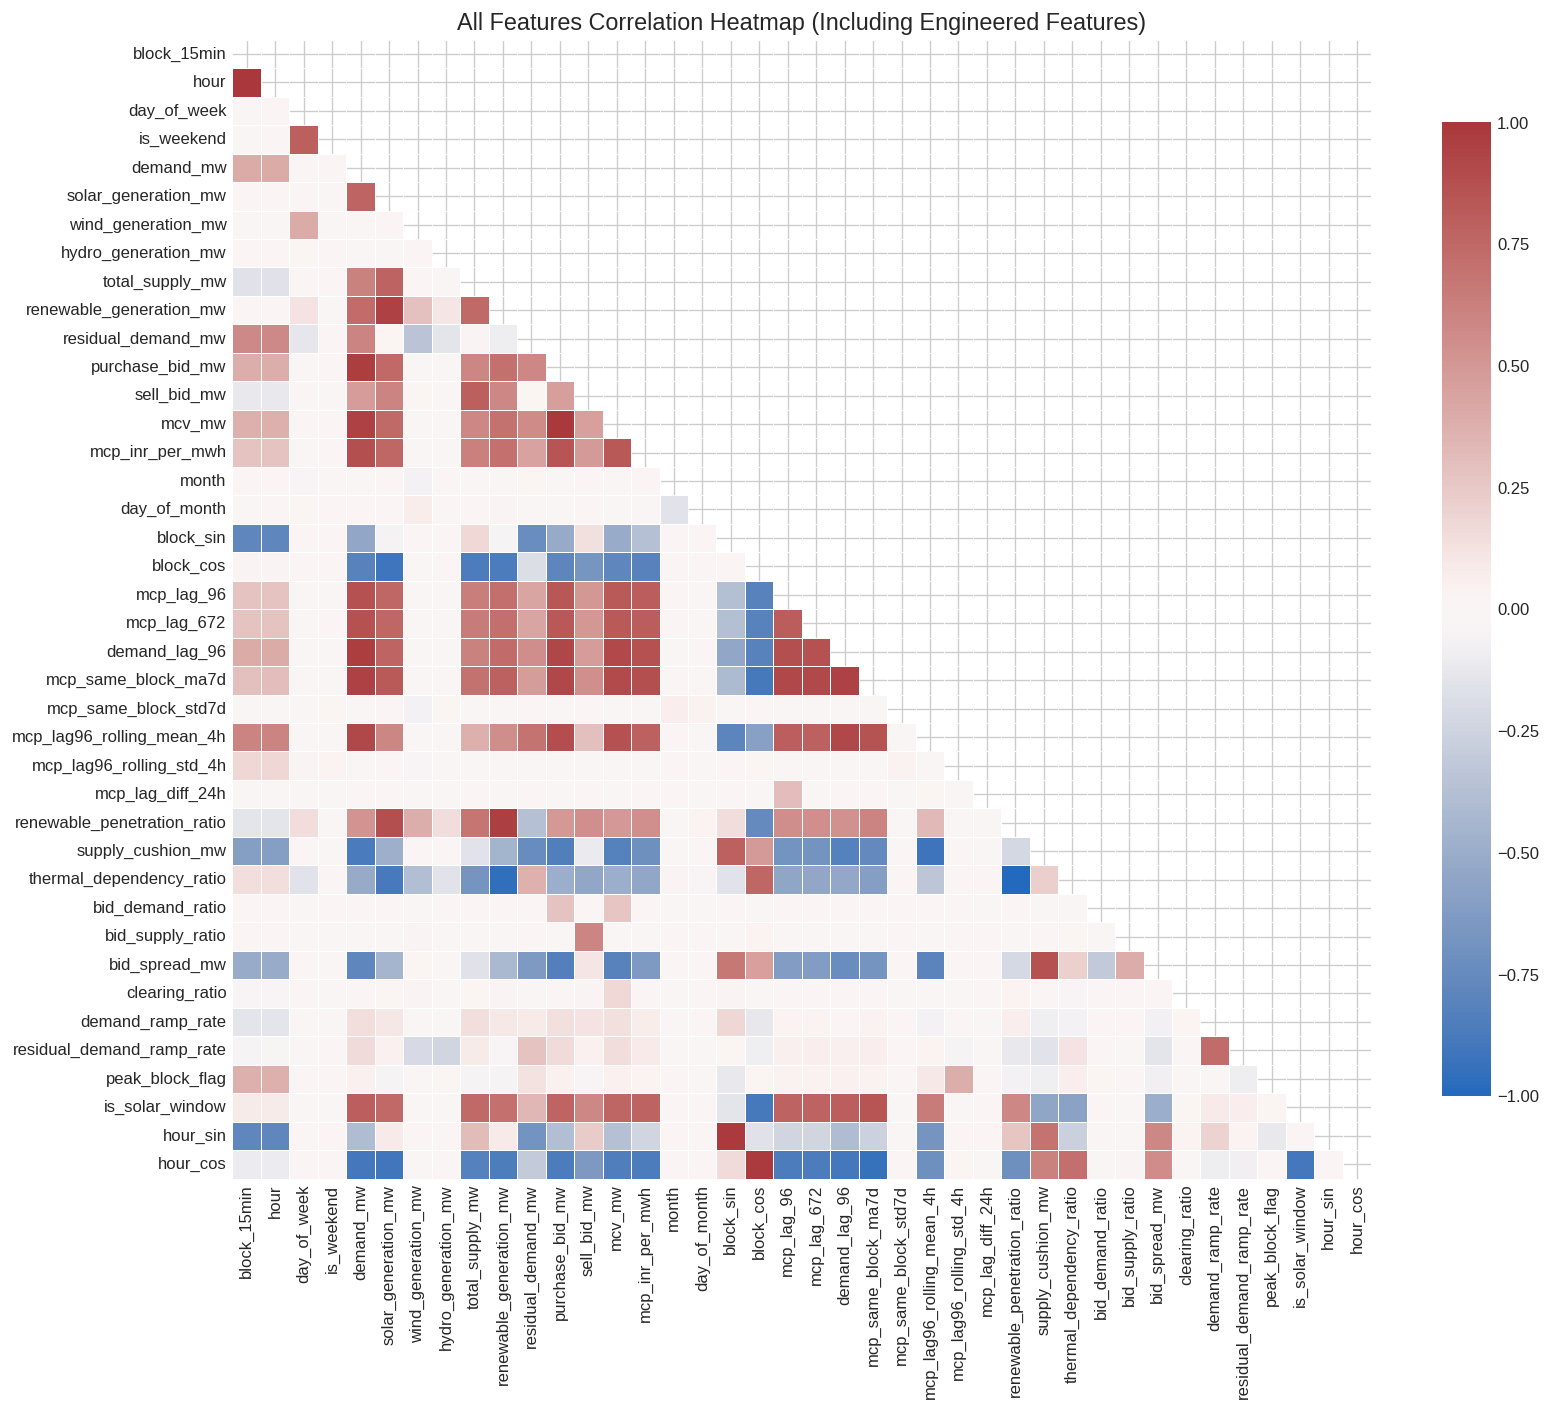

In [6]:
plt.figure(figsize=(14, 12))

num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

target_corr = corr['mcp_inr_per_mwh'].sort_values(ascending=False)
print("Top Feature Correlations with Target (MCP):")
print(target_corr)

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='vlag', vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.3, cbar_kws={"shrink": .8}, annot=False)
plt.title('All Features Correlation Heatmap (Including Engineered Features)')
plt.tight_layout()
plt.show()


### 6. Engineered Ratios & Market Interactions

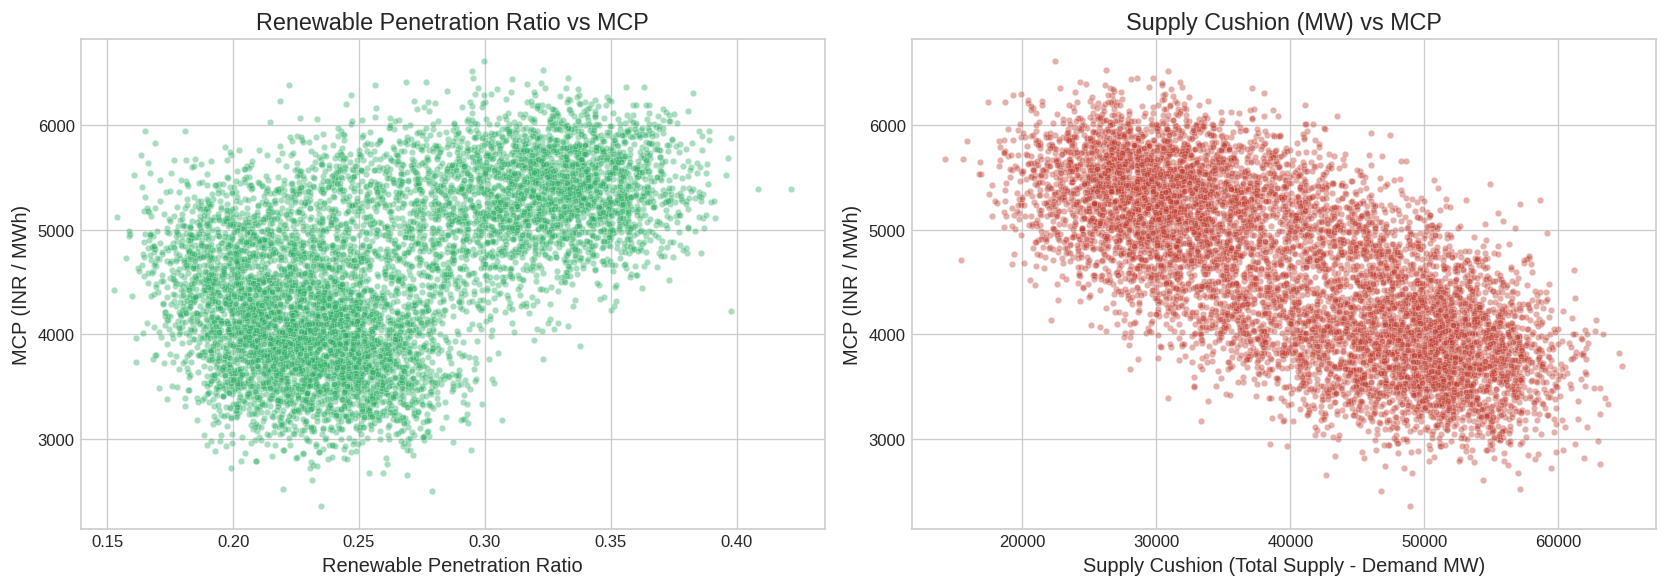

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='renewable_penetration_ratio', y='mcp_inr_per_mwh', ax=axes[0], alpha=0.4, color='#27ae60', s=15)
axes[0].set_title('Renewable Penetration Ratio vs MCP')
axes[0].set_xlabel('Renewable Penetration Ratio')
axes[0].set_ylabel('MCP (INR / MWh)')

sns.scatterplot(data=df, x='supply_cushion_mw', y='mcp_inr_per_mwh', ax=axes[1], alpha=0.4, color='#c0392b', s=15)
axes[1].set_title('Supply Cushion (MW) vs MCP')
axes[1].set_xlabel('Supply Cushion (Total Supply - Demand MW)')
axes[1].set_ylabel('MCP (INR / MWh)')

plt.tight_layout()
plt.show()
